In [1]:
import math
import numpy as np
import pandas as pd

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("../data/house_sales.csv")

In [3]:
df.shape

(15, 11)

In [4]:
df.head()

,address,city,date_of_sale,sold_price,bedrooms,sq_ft,type,build_age,school_score,unemployment,interest_rate
0,460 N Civic Dr #409,Walnut Creek,1/28/22,347000,1,704,Condo,53,23,4.0,3.55
1,1875 Granada Dr,Concord,5/12/21,780000,3,1732,Single-family,76,11,5.8,3.00
2,1628 Armstrong Ct,Concord,12/22/23,715351,3,1445,Townhome,48,13,3.8,6.67
3,5502 Sun Cloud Ct,Concord,3/20/24,1300000,4,2331,Single-family,40,17,3.9,6.74
4,2720 Atlantic St,Concord,3/10/23,515000,2,742,Single-family,83,9,3.5,6.73


# Example preprocessing step

In [5]:
# type -> dummy columns
# school score -> normalize this

In [15]:
class TypeDummyCreator(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Fit logic, if needed, goes here
        return self

    def transform(self, X):
        # Transform logic: Assume X is a DataFrame
        # For example, let's say we want to scale the "feature_1" column
        X_transformed = X.copy().reset_index().drop("index", axis=1)
        dummy_df = pd.get_dummies(X_transformed["type"]).reset_index().drop("index", axis=1).astype("int")
        X_transformed_out = pd.concat([
            X_transformed[[x for x in X_transformed.columns if x != "type"]],
            dummy_df,
        ], axis=1)
        return X_transformed_out

In [16]:
pipeline = Pipeline(
    [
        ("type_of_home_dummy", TypeDummyCreator()),
    ]
)

In [17]:
df2 = pipeline.fit_transform(df)

In [18]:
df2.head()

,address,city,date_of_sale,sold_price,bedrooms,sq_ft,build_age,school_score,unemployment,interest_rate,Condo,Single-family,Townhome
0,460 N Civic Dr #409,Walnut Creek,1/28/22,347000,1,704,53,23,4.0,3.55,1,0,0
1,1875 Granada Dr,Concord,5/12/21,780000,3,1732,76,11,5.8,3.00,0,1,0
2,1628 Armstrong Ct,Concord,12/22/23,715351,3,1445,48,13,3.8,6.67,0,0,1
3,5502 Sun Cloud Ct,Concord,3/20/24,1300000,4,2331,40,17,3.9,6.74,0,1,0
4,2720 Atlantic St,Concord,3/10/23,515000,2,742,83,9,3.5,6.73,0,1,0


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [20]:
pipeline2 = Pipeline(
    [
        ("type_of_home_dummy", TypeDummyCreator()),
        ("normalize", StandardScaler()),
    ]
)

In [21]:
df3 = pipeline2.fit_transform(df[["type", "school_score"]])

In [27]:
pipeline3 = Pipeline(
    [
        ("type_of_home_dummy", TypeDummyCreator()),
        ("normalize", StandardScaler()),
        ("regression", RandomForestRegressor()),
    ]
)

In [28]:
features = ["type", "school_score"]
label = "sold_price"

In [29]:
df_test = df[["type", "school_score", "sold_price"]].sample(10000, replace=True).copy()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(df_test[features], df_test[label], test_size=0.2, random_state=1019)

In [32]:
pipeline3.fit(X_train, y_train)

,steps,"[('type_of_home_dummy', ...), ('normalize', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [34]:
pipeline3.predict(X_test)

array([ 320000.        ,  664009.97552563,  570590.02658181, ...,
        320000.        ,  490000.        , 1210500.        ],
      shape=(2000,))

In [35]:
from matplotlib import pyplot as plt

In [38]:
from sklearn.metrics import mean_squared_error

In [40]:
math.sqrt(mean_squared_error(pipeline3.predict(X_test), y_test))

33933.55916031067

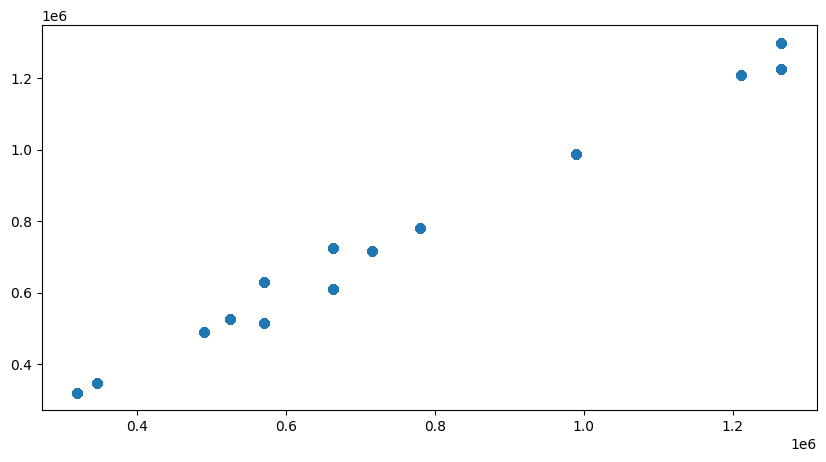

In [36]:
plt.figure(figsize=(10,5))
plt.scatter(pipeline3.predict(X_test), y_test)
plt.show()